In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

data_path = "LUCAS.2009_abs.csv"
df = pd.read_csv(data_path)

df = df.dropna()
#pH.in.CaCl2,pH.in.H2O,OC,CaCO3,N,P,K,CEC
soil_features = ["OC", "N", "P", "K", "CEC","pH.in.CaCl2","pH.in.H2O","CaCO3"]
X = df.iloc[:,:4200]
y = df[soil_features]

#8:2比例划分训练集与验证集
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
) #保证划分结果可复现
# 合并特征与标签
train_df = y_train.copy()
val_df = y_val.copy()

# 数理统计计算
def calculate_statistics(data_df, feature_cols):
    stats = []
    for col in feature_cols:
        col_data = data_df[col]
        stat_dict = {
            "Soil properties": col,
            "Samples": len(col_data),
            "Min": round(col_data.min(), 2),
            "Max": round(col_data.max(), 2),
            "Mean": round(col_data.mean(), 2),
            "Standard deviation": round(col_data.std(), 2)
        }
        stats.append(stat_dict)
    return pd.DataFrame(stats)
# 计算训练集和验证集的统计结果
train_stats = calculate_statistics(train_df, soil_features)
val_stats = calculate_statistics(val_df, soil_features)

print(train_stats)
print(val_stats)

  Soil properties  Samples   Min      Max    Mean  Standard deviation
0              OC    15228  0.00   586.80   50.38               91.97
1               N    15228  0.00    38.60    2.95                3.80
2               P    15228  0.00   789.80   30.12               31.76
3               K    15228  0.00  7342.00  198.27              235.55
4             CEC    15228  0.00   234.00   15.88               14.81
5     pH.in.CaCl2    15228  2.61     9.25    5.60                1.43
6       pH.in.H2O    15228  3.21    10.08    6.20                1.35
7           CaCO3    15228  0.00   944.00   51.86              126.10
  Soil properties  Samples   Min      Max    Mean  Standard deviation
0              OC     3807  0.00   577.00   48.39               88.41
1               N     3807  0.00    34.40    2.83                3.55
2               P     3807  0.00  1366.40   29.87               36.90
3               K     3807  0.00  4665.00  192.18              202.31
4             CEC   

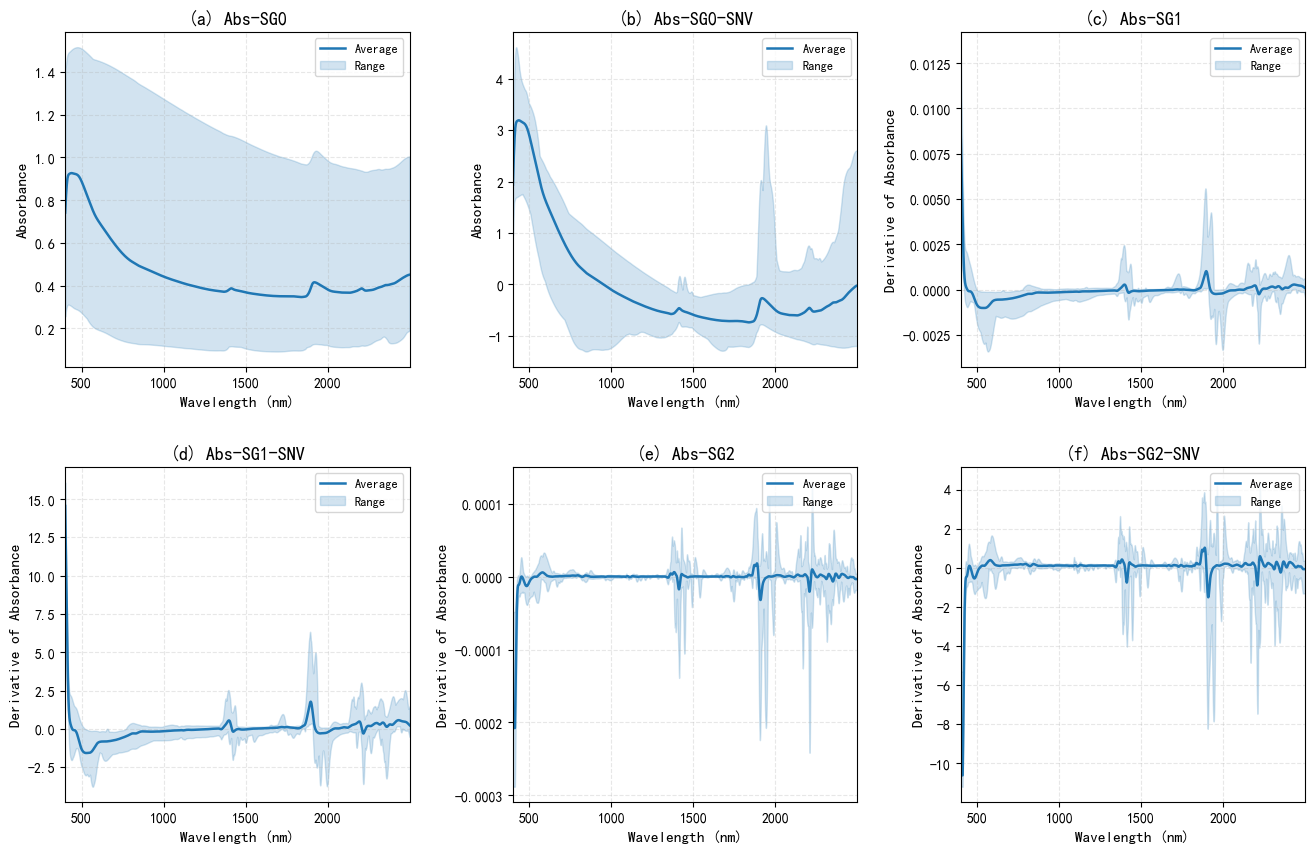

In [2]:
#数据预处理
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
from scipy.signal import savgol_filter
import matplotlib.gridspec as gridspec
X_cols = df.columns[:4200]
wavelengths = np.array([float(col.replace("spc.", "")) for col in X_cols])
X_spectra = X[X_cols].values

#sg光滑
def sg_smoothing(spectra, window_length=50, polyorder=2, deriv=0):
    sg_spectra = np.apply_along_axis(
        lambda x: savgol_filter(x, window_length=window_length, polyorder=polyorder, deriv=deriv),
        axis=1,
        arr=spectra
    )
    return sg_spectra
#标准正态snv
def snv_transform(spectra):
    # 对每个样本计算（x - 均值）/ 标准差
    snv_spectra = np.apply_along_axis(
        lambda x: (x - np.mean(x)) / np.std(x) if np.std(x) != 0 else x,
        axis=1,
        arr=spectra
    )
    return snv_spectra

window_length = 50  # SG窗口大小
polyorder = 2       # 多项式阶数

#Abs-SG0
sg0 = sg_smoothing(X_spectra, window_length=window_length, polyorder=polyorder, deriv=0)
#Abs-SG0-SNV
sg0_snv = snv_transform(sg0)
#Abs-SG1
sg1 = sg_smoothing(X_spectra, window_length=window_length, polyorder=polyorder, deriv=1)
#Abs-SG1-SNV
sg1_snv = snv_transform(sg1)
#Abs-SG2
sg2 = sg_smoothing(X_spectra, window_length=window_length, polyorder=polyorder, deriv=2)
#Abs-SG2-SNV
sg2_snv = snv_transform(sg2)
# 整理预处理结果（键：方法名，值：处理后的数据）
preprocessed_dict = {
    "Abs-SG0": sg0,
    "Abs-SG0-SNV": sg0_snv,
    "Abs-SG1": sg1,
    "Abs-SG1-SNV": sg1_snv,
    "Abs-SG2": sg2,
    "Abs-SG2-SNV": sg2_snv
}

plt.rcParams['axes.unicode_minus']=False
plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.3, wspace=0.3)
plot_idx = 0

for method_name, spectra_data in preprocessed_dict.items():
    mean_spec = np.mean(spectra_data, axis=0)  # 所有样本的平均光谱
    min_spec = np.min(spectra_data, axis=0)    # 光谱下限
    max_spec = np.max(spectra_data, axis=0)    # 光谱上限
    ax = plt.subplot(gs[plot_idx])

    ax.plot(wavelengths, mean_spec, color='#1f77b4', linewidth=1.8, label='Average')
    ax.fill_between(wavelengths, min_spec, max_spec, color='#1f77b4', alpha=0.2, label='Range')
    ax.set_title(f'({chr(97 + plot_idx)}) {method_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Wavelength (nm)', fontsize=11)
    y_label = 'Absorbance' if 'SG0' in method_name else 'Derivative of Absorbance'
    ax.set_ylabel(y_label, fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_xlim(wavelengths.min(), wavelengths.max())

    plot_idx += 1

plt.savefig('光谱预处理结果图.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



In [3]:
#模型构建
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 3),stride=stride, padding=(0, 1), bias=False)  # 保持宽度不变
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels * self.expansion,kernel_size=(1, 3), stride=1, padding=(0, 1), bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels * self.expansion)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out
class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1), stride=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=(1, 3),
                               stride=stride, padding=(0, 1), bias=False)  # 3×3卷积
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion,
                               kernel_size=(1, 1), stride=1, bias=False)  # 1×1扩展
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

# ResNet类
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1):
        super(ResNet, self).__init__()
        self.in_channels = 6 #初始通道数

        self.conv1 = nn.Conv2d(1, self.in_channels, kernel_size=(1,7),
                               stride=2, padding=(0, 3), bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=(1,3), stride=2, padding=(0,1))

        # 残差层
        self.layer1 = self._make_layer(block, 6, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 6, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 12, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 12, layers[3], stride=2)

        #第二个最大池化层：Maxpool(1,3)-2
        self.maxpool2 = nn.MaxPool2d(kernel_size=(1, 3), stride=2, padding=(0, 1))
        # 全局平均池化
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # 全连接层
        self.fc1 = nn.Linear(12 * block.expansion, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn_fc2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.bn_fc3 = nn.BatchNorm1d(64)
        # 输出层
        self.fc_out = nn.Linear(64, num_classes)
#残差块堆叠层
    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                          kernel_size=(1, 1), stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)
    #前向传播
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.maxpool2(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        # 全连接层
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn_fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.bn_fc3(x)
        x = self.relu(x)
        # 输出层
        x = self.fc_out(x)
        return x

def resnet18(num_classes=8):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)
def resnet34(num_classes=8):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes)
def resnet50(num_classes=8):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes)
# -------------------------- 测试模型并打印结构 --------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_A = resnet18().to(device)
    model_B = resnet34().to(device)
    model_C = resnet50().to(device)
    # 打印模型结构（输入形状需与光谱数据匹配：(1,1,4200)）
    print("模型A结构：")
    summary(model_A, input_size=(1, 1, 4200))  # (通道数, 高度, 宽度)
    print("\n" + "="*50)
    print("模型B结构：")
    summary(model_B, input_size=(1, 1, 4200))
    print("\n" + "="*50)
    print("模型C结构：")
    summary(model_C, input_size=(1, 1, 4200))

模型A结构：
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 6, 1, 2100]              42
       BatchNorm2d-2           [-1, 6, 1, 2100]              12
              ReLU-3           [-1, 6, 1, 2100]               0
         MaxPool2d-4           [-1, 6, 1, 1050]               0
            Conv2d-5           [-1, 6, 1, 1050]             108
       BatchNorm2d-6           [-1, 6, 1, 1050]              12
              ReLU-7           [-1, 6, 1, 1050]               0
            Conv2d-8           [-1, 6, 1, 1050]             108
       BatchNorm2d-9           [-1, 6, 1, 1050]              12
             ReLU-10           [-1, 6, 1, 1050]               0
       BasicBlock-11           [-1, 6, 1, 1050]               0
           Conv2d-12           [-1, 6, 1, 1050]             108
      BatchNorm2d-13           [-1, 6, 1, 1050]              12
             ReLU-14           [

In [4]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# ==================== 数据标准化 ====================
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
spectra_scaler = StandardScaler()
X_train_reshaped = X_train.values.reshape(-1, 4200)
X_val_reshaped = X_val.values.reshape(-1, 4200)
X_train_scaled = spectra_scaler.fit_transform(X_train_reshaped)
X_val_scaled = spectra_scaler.transform(X_val_reshaped)
target_scalers = {}
y_train_scaled = np.zeros_like(y_train.values)
y_val_scaled = np.zeros_like(y_val.values)
for i, feature in enumerate(soil_features):
    scaler = StandardScaler()
    y_train_scaled[:, i] = scaler.fit_transform(y_train.iloc[:, i].values.reshape(-1, 1)).flatten()
    y_val_scaled[:, i] = scaler.transform(y_val.iloc[:, i].values.reshape(-1, 1)).flatten()
    target_scalers[feature] = scaler
# 将数据转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train_scaled).reshape(-1, 1, 1, 4200)
X_val_tensor = torch.FloatTensor(X_val_scaled).reshape(-1, 1, 1, 4200)
y_train_tensor = torch.FloatTensor(y_train_scaled)
y_val_tensor = torch.FloatTensor(y_val_scaled)

# 创建数据集和数据加载器
batch_size = 32
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [5]:
#训练函数
def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.001, device='cpu'):
    model = model.to(device)
    # 损失函数和优化器
    criterion = nn.MSELoss(reduction='none')
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)  # 优化器：AdamW
    # 学习率调度器
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    # 记录训练历史
    history = {
        'train_loss': [],
        'pH.in.H2O_loss': [],
        'pH.in.CaCl2_loss': [],
        'OC_loss': [],
        'CaCO3_loss':[],
        'N_loss': [],
        'P_loss': [],
        'K_loss': [],
        'CEC_loss': [],
        'val_loss': [],
        'val_pH.in.H2O_loss': [],
        'val_PH.in.CaCl2_loss': [],
        'val_OC_loss': [],
        'val_CaCO3_loss': [],
        'val_N_loss': [],
        'val_P_loss': [],
        'val_K_loss': [],
        'val_CEC_loss': []
    }
    property_indices = {
        'OC': 0,
        'N': 1,
        'P': 2,
        'K': 3,
        'CEC': 4,
        'pH.in.CaCl2': 5,
        'pH.in.H2O': 6,
        'CaCO3': 7
    }
    print(f"\n开始训练 {model.__class__.__name__}...")
    for epoch in range(num_epochs):
        """训练"""
        model.train()
        train_loss = 0.0
        property_losses_train = {
            'pH.in.CaCl2': 0.0, 'pH.in.H2O': 0.0,'OC': 0.0, 'CaCO3': 0.0, 'N': 0.0,
            'P': 0.0, 'K': 0.0, 'CEC': 0.0
        }
        total_samples_train = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            batch_size = batch_X.size(0)
            total_samples_train += batch_size
            optimizer.zero_grad()
            outputs = model(batch_X)
            # 计算每个样本每个属性的损失
            losses = criterion(outputs, batch_y)
            # 计算总损失
            total_loss = losses.mean()
            total_loss.backward()
            # 梯度裁剪
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            # 累加总损失
            train_loss += total_loss.item() * batch_size
            # 计算每个属性的损失并累加
            with torch.no_grad():
                for prop, idx in property_indices.items():
                    prop_loss = losses[:, idx].mean().item()
                    property_losses_train[prop] += prop_loss * batch_size
        # 计算平均损失
        avg_train_loss = train_loss / total_samples_train
        avg_property_losses_train = {prop: loss / total_samples_train
                                     for prop, loss in property_losses_train.items()}
        """验证"""
        model.eval()
        val_loss = 0.0
        # 初始化每个属性的验证损失累加器
        property_losses_val = {
            'pH.in.CaCl2': 0.0, 'pH.in.H2O': 0.0, 'OC': 0.0, 'CaCO3': 0.0, 'N': 0.0,
            'P': 0.0, 'K': 0.0, 'CEC': 0.0
        }
        total_samples_val = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                batch_size = batch_X.size(0)
                total_samples_val += batch_size
                outputs = model(batch_X)
                losses = criterion(outputs, batch_y)
                total_loss = losses.mean()
                val_loss += total_loss.item() * batch_size
                for prop, idx in property_indices.items():
                    prop_loss = losses[:, idx].mean().item()
                    property_losses_val[prop] += prop_loss * batch_size
        # 计算平均验证损失
        avg_val_loss = val_loss / total_samples_val
        avg_property_losses_val = {prop: loss / total_samples_val
                                   for prop, loss in property_losses_val.items()}
        # 更新学习率
        scheduler.step(avg_val_loss)
        # 记录历史
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['pH.in.H2O_loss'].append(avg_property_losses_train['pH.in.H2O'])
        history['pH.in.CaCl2_loss'].append(avg_property_losses_train['pH.in.CaCl2'])
        history['OC_loss'].append(avg_property_losses_train['OC'])
        history['CaCO3_loss'].append(avg_property_losses_train['CaCO3'])
        history['N_loss'].append(avg_property_losses_train['N'])
        history['P_loss'].append(avg_property_losses_train['P'])
        history['K_loss'].append(avg_property_losses_train['K'])
        history['CEC_loss'].append(avg_property_losses_train['CEC'])
        history['val_pH.in.H2O_loss'].append(avg_property_losses_val['pH.in.H2O'])
        history['val_PH.in.CaCl2_loss'].append(avg_property_losses_val['pH.in.CaCl2'])
        history['val_OC_loss'].append(avg_property_losses_val['OC'])
        history['val_CaCO3_loss'].append(avg_property_losses_val['CaCO3'])
        history['val_N_loss'].append(avg_property_losses_val['N'])
        history['val_P_loss'].append(avg_property_losses_val['P'])
        history['val_K_loss'].append(avg_property_losses_val['K'])
        history['val_CEC_loss'].append(avg_property_losses_val['CEC'])
        # 添加学习率记录
        if 'lr' not in history:
            history['lr'] = []
        history['lr'].append(optimizer.param_groups[0]['lr'])
        # 打印进度
        print(f'Epoch [{epoch+1:03d}/{num_epochs:03d}]')
        print(f'loss: {avg_train_loss:.4f}-pH.in.CaCl2_output:{avg_property_losses_train["pH.in.CaCl2"]:.4f}-pH.in.H2O_output:{avg_property_losses_train["pH.in.H2O"]:.4f}-OC_output:{avg_property_losses_train["OC"]:.4f}-CaCO3_output:{avg_property_losses_train["CaCO3"]:.4f}-N_output:{avg_property_losses_train["N"]:.4f}-P_output:{avg_property_losses_train["P"]:.4f}-K_output:{avg_property_losses_train["K"]:.4f}-CEC_output:{avg_property_losses_train["CEC"]:.4f}-val_loss: {avg_val_loss:.4f}-val_pH.in.CaCl2_output:{avg_property_losses_train["pH.in.CaCl2"]:.4f}-val_pH.in.H2O_output:{avg_property_losses_val["pH.in.H2O"]:.4f}-val_OC_output:{avg_property_losses_val["OC"]:.4f}-val_CaCO3_output:{avg_property_losses_val["CaCO3"]:.4f}-val_N_output:{avg_property_losses_val["N"]:.4f}-val_P_output:{avg_property_losses_val["P"]:.4f}-val_K_output:{avg_property_losses_val["K"]:.4f}-val_CEC_output:{avg_property_losses_val["CEC"]:.4f}')
    return model, history

# ==================== 修改评估函数 ====================
def evaluate_model(model, val_loader, target_scalers, soil_features, device='cpu'):
    """评估模型性能"""
    model.eval()
    criterion = nn.MSELoss()  # 这里保持默认，因为不需要每个属性的损失

    total_loss = 0.0
    all_predictions_scaled = []
    all_targets_scaled = []

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)

            loss = criterion(outputs, batch_y)
            total_loss += loss.item() * batch_X.size(0)

            all_predictions_scaled.append(outputs.cpu().numpy())
            all_targets_scaled.append(batch_y.cpu().numpy())

    avg_loss = total_loss / len(val_loader.dataset)

    # 合并所有批次的预测和真实值（标准化后的）
    all_predictions_scaled = np.vstack(all_predictions_scaled)
    all_targets_scaled = np.vstack(all_targets_scaled)

    # 反标准化到原始尺度
    all_predictions = np.zeros_like(all_predictions_scaled)
    all_targets = np.zeros_like(all_targets_scaled)

    for i, feature in enumerate(soil_features):
        scaler = target_scalers[feature]
        all_predictions[:, i] = scaler.inverse_transform(all_predictions_scaled[:, i].reshape(-1, 1)).flatten()
        all_targets[:, i] = scaler.inverse_transform(all_targets_scaled[:, i].reshape(-1, 1)).flatten()

    # 计算R²分数（在原始尺度上）
    from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
    r2_scores = []
    mse_scores = []
    mae_scores = []

    for i in range(all_targets.shape[1]):
        r2 = r2_score(all_targets[:, i], all_predictions[:, i])
        mse = mean_squared_error(all_targets[:, i], all_predictions[:, i])
        mae = mean_absolute_error(all_targets[:, i], all_predictions[:, i])

        r2_scores.append(r2)
        mse_scores.append(mse)
        mae_scores.append(mae)

    return avg_loss, all_predictions, all_targets, r2_scores, mse_scores, mae_scores

In [ ]:
device = torch.device("cuda")
# 训练参数
num_epochs = 40
learning_rate = 0.001
# 模型A
print("\n" + "-"*60)
print("训练模型A")
print("-"*60)
model_A_trained, history_A = train_model(
    model_A, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate, device=device
)
# 模型B
print("\n" + "-"*60)
print("训练模型B")
print("-"*60)
model_B_trained, history_B = train_model(
    model_B, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate, device=device
)
# 模型C
print("\n" + "-"*60)
print("训练模型C")
print("-"*60)
model_C_trained, history_C = train_model(
    model_C, train_loader, val_loader,
    num_epochs=num_epochs, lr=learning_rate, device=device
)

In [ ]:
models = {
    "Model A": model_A_trained,
    "Model B": model_B_trained,
    "Model C": model_C_trained
}
results = {}
for model_name, model in models.items():
    print(f"\n{model_name}:")
    val_loss, predictions, targets, r2_scores, mse_scores, mae_scores = evaluate_model(
        model, val_loader, target_scalers, soil_features, device=device
    )
    rmse_scores = [np.sqrt(mse) for mse in mse_scores]
    results[model_name] = {
        'val_loss': val_loss,
        'r2_scores': r2_scores,
        'mse_scores': mse_scores,
        'rmse_scores': rmse_scores,
        'mae_scores': mae_scores,
        'predictions': predictions,
        'targets': targets
    }
    print(f"  Validation Loss (MSE on scaled data): {val_loss:.6f}")
    print(f"  R² Scores for each soil property (original scale):")
    for i, (feature, r2) in enumerate(zip(soil_features, r2_scores)):
        print(f"    {feature}: R²={r2:.4f}, MSE={mse_scores[i]:.4f}, MAE={mae_scores[i]:.4f}")
    print(f"  Average R² Score: {np.mean(r2_scores):.4f}")
    print(f"  Average MSE: {np.mean(mse_scores):.4f}")
    print(f"  Average MAE: {np.mean(mae_scores):.4f}")

# 1. 训练历史可视化
def plot_training_history(history, model_name):
    """绘制训练历史"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 损失曲线
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title(f'{model_name} - Training History', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 学习率曲线
    axes[1].plot(epochs, history['lr'], 'g-', linewidth=2)
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Learning Rate', fontsize=12)
    axes[1].set_title(f'{model_name} - Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.savefig(f'{model_name}_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history_A, "Model_A_ResNet18")
plot_training_history(history_B, "Model_B_ResNet34")
plot_training_history(history_C, "Model_C_ResNet50")

# 2. 比较三个模型的性能
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 验证损失比较
model_names = list(results.keys())
val_losses = [results[name]['val_loss'] for name in model_names]
avg_r2_scores = [np.mean(results[name]['r2_scores']) for name in model_names]
avg_mse_scores = [np.mean(results[name]['mse_scores']) for name in model_names]

axes[0].bar(model_names, val_losses, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Validation Loss (MSE on scaled)', fontsize=12)
axes[0].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# 在柱状图上添加数值标签
for i, (bar, val) in enumerate(zip(axes[0].patches, val_losses)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# R²分数比较
axes[1].bar(model_names, avg_r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Average R² Score', fontsize=12)
axes[1].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# 在柱状图上添加数值标签
for i, (bar, val) in enumerate(zip(axes[1].patches, avg_r2_scores)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# MSE比较
axes[2].bar(model_names, avg_mse_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_ylabel('Average MSE', fontsize=12)
axes[2].set_title('MSE Comparison (original scale)', fontsize=14, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

# 在柱状图上添加数值标签
for i, (bar, val) in enumerate(zip(axes[2].patches, avg_mse_scores)):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. 详细R²分数对比（每个土壤属性）
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(soil_features))
width = 0.25

for i, (model_name, result) in enumerate(results.items()):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, result['r2_scores'], width, label=model_name)

    # 在每个柱子上添加数值
    for bar, r2 in zip(bars, result['r2_scores']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{r2:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Soil Properties', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('R² Scores by Soil Property for Each Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(soil_features, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('r2_scores_by_property.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 预测 vs 真实值散点图（以最佳模型为例）
best_model_name = min(results, key=lambda x: results[x]['val_loss'])
best_result = results[best_model_name]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (feature, ax) in enumerate(zip(soil_features, axes)):
    if i < len(soil_features):
        pred = best_result['predictions'][:, i]
        true = best_result['targets'][:, i]

        # 计算该属性的R²
        from sklearn.metrics import r2_score
        r2 = r2_score(true, pred)

        # 绘制散点图
        ax.scatter(true, pred, alpha=0.6, s=30, edgecolors='w', linewidth=0.5)

        # 添加对角线（理想预测线）
        min_val = min(true.min(), pred.min())
        max_val = max(true.max(), pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

        ax.set_xlabel('True Values', fontsize=10)
        ax.set_ylabel('Predicted Values', fontsize=10)
        ax.set_title(f'{feature}\nR² = {r2:.3f}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.suptitle(f'Predictions vs True Values - {best_model_name}\n(Original Scale)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('predictions_vs_true.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== 7. 保存模型和结果 ====================
print("\n" + "="*60)
print("7. 保存模型和结果")
print("="*60)

import pickle
import json

# 保存训练好的模型
torch.save(model_A_trained.state_dict(), 'model_A_resnet18_modified.pth')
torch.save(model_B_trained.state_dict(), 'model_B_resnet34_modified.pth')
torch.save(model_C_trained.state_dict(), 'model_C_resnet50_modified.pth')

print("模型已保存为: model_A_resnet18_modified.pth, model_B_resnet34_modified.pth, model_C_resnet50_modified.pth")

# 保存标准化器
with open('target_scalers.pkl', 'wb') as f:
    pickle.dump(target_scalers, f)

# 保存训练历史
with open('training_history_modified.pkl', 'wb') as f:
    pickle.dump({
        'history_A': history_A,
        'history_B': history_B,
        'history_C': history_C
    }, f)

# 保存评估结果
results_to_save = {}
for model_name, result in results.items():
    results_to_save[model_name] = {
        'val_loss': float(result['val_loss']),
        'r2_scores': [float(r2) for r2 in result['r2_scores']],
        'mse_scores': [float(mse) for mse in result['mse_scores']],
        'mae_scores': [float(mae) for mae in result['mae_scores']],
        'avg_r2': float(np.mean(result['r2_scores'])),
        'avg_mse': float(np.mean(result['mse_scores'])),
        'avg_mae': float(np.mean(result['mae_scores']))
    }

with open('model_results_modified.json', 'w') as f:
    json.dump(results_to_save, f, indent=4)


# 打印最佳模型
print("\n" + "="*60)
print("最佳模型总结")
print("="*60)

best_model_info = min(results_to_save.items(), key=lambda x: x[1]['val_loss'])
print(f"最佳模型: {best_model_info[0]}")
print(f"验证损失 (标准化尺度): {best_model_info[1]['val_loss']:.6f}")
print(f"平均R²分数 (原始尺度): {best_model_info[1]['avg_r2']:.4f}")
print(f"平均MSE (原始尺度): {best_model_info[1]['avg_mse']:.4f}")
print(f"平均MAE (原始尺度): {best_model_info[1]['avg_mae']:.4f}")

print("\n各属性R²分数 (原始尺度):")
for feature, r2 in zip(soil_features, best_model_info[1]['r2_scores']):
    print(f"  {feature}: {r2:.4f}")

print("\n训练完成!")

In [ ]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
# 损失函数曲线绘制
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title(f'{model_name}Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    # 学习率曲线
    axes[1].plot(epochs, history['lr'], 'g-', linewidth=2)
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Learning Rate', fontsize=12)
    axes[1].set_title(f'{model_name}learning data', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')
    plt.tight_layout()
    plt.savefig(f'{model_name}的损失函数.png', dpi=300, bbox_inches='tight')
    plt.show()
plot_training_history(history_A, "Model_A_ResNet18")
plot_training_history(history_B, "Model_B_ResNet34")
plot_training_history(history_C, "Model_C_ResNet50")

In [ ]:
test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
models_dict = {
    "Model A": model_A_trained,
    "Model B": model_B_trained,
    "Model C": model_C_trained
}
for model_name, model in models_dict.items():
    print(f"\n{model_name}:")
    test_loss, predictions, targets, r2_scores, mse_scores, mae_scores = evaluate_model(
        model, test_loader, target_scalers, soil_features, device=device
    )
    #RMSE
    rmse_scores = [np.sqrt(mse) for mse in mse_scores]

    print(f"各土壤指标性能:")
    print(f"{'指标':<15} {'R²':<10} {'RMSE':<10}")
    print(f"{'-'*15} {'-'*10} {'-'*10}")
    for i, feature in enumerate(soil_features):
        print(f"{feature:<15} {r2_scores[i]:<10.4f} {rmse_scores[i]:<10.4f}")
    avg_r2 = np.mean(r2_scores)
    avg_rmse = np.mean(rmse_scores)
    print(f"{'-'*15} {'-'*10} {'-'*10}")

In [ ]:
best_model_name = min(results, key=lambda x: results[x]['val_loss'])
best_result = results[best_model_name]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, (feature, ax) in enumerate(zip(soil_features, axes)):
    if i < len(soil_features):
        pred = best_result['predictions'][:, i]
        true = best_result['targets'][:, i]
        # 计算该属性的R²
        from sklearn.metrics import r2_score
        r2 = r2_score(true, pred)

        # 绘制散点图
        ax.scatter(true, pred, alpha=0.6, s=30, edgecolors='w', linewidth=0.5)

        # 添加对角线（理想预测线）
        min_val = min(true.min(), pred.min())
        max_val = max(true.max(), pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

        ax.set_xlabel('True Values', fontsize=10)
        ax.set_ylabel('Predicted Values', fontsize=10)
        ax.set_title(f'{feature}\nR² = {r2:.3f}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)

plt.suptitle(f'Predictions vs True Values - {best_model_name}\n(Original Scale)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('predictions_vs_true.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
preprocessing_methods = [
    "Abs-SG0",
    "Abs-SG0-SNV",
    "Abs-SG1",
    "Abs-SG1-SNV",
    "Abs-SG2",
    "Abs-SG2-SNV"
]
preprocessing_results = {}
for method_idx, method_name in enumerate(preprocessing_methods, 1):
    print(f"\n{'='*60}")
    print(f"处理预处理方法: {method_name} (PP{method_idx})")
    print(f"{'='*60}")
    if method_name == "Abs-SG0":
        X_pp = sg0
    elif method_name == "Abs-SG0-SNV":
        X_pp = sg0_snv
    elif method_name == "Abs-SG1":
        X_pp = sg1
    elif method_name == "Abs-SG1-SNV":
        X_pp = sg1_snv
    elif method_name == "Abs-SG2":
        X_pp = sg2
    else:
        X_pp = sg2_snv
    train_indices = X_train.index
    test_indices = X_val.index
    X_train_pp = X_pp[train_indices]
    X_test_pp = X_pp[test_indices]
    spectra_scaler_pp = StandardScaler()
    X_train_pp_scaled = spectra_scaler_pp.fit_transform(X_train_pp)
    X_test_pp_scaled = spectra_scaler_pp.transform(X_test_pp)
    X_train_tensor_pp = torch.FloatTensor(X_train_pp_scaled).reshape(-1, 1, 1, 4200)
    X_test_tensor_pp = torch.FloatTensor(X_test_pp_scaled).reshape(-1, 1, 1, 4200)
    y_train_tensor_pp = torch.FloatTensor(y_train_scaled)
    y_test_tensor_pp = torch.FloatTensor(y_val_scaled)
    batch_size = 32
    train_dataset_pp = TensorDataset(X_train_tensor_pp, y_train_tensor_pp)
    test_dataset_pp = TensorDataset(X_test_tensor_pp, y_test_tensor_pp)
    train_loader_pp = DataLoader(train_dataset_pp, batch_size=batch_size, shuffle=True)
    test_loader_pp = DataLoader(test_dataset_pp, batch_size=batch_size, shuffle=False)
    # 模型B
    model_B_pp = resnet34(num_classes=8).to(device)
    # 训练参数
    num_epochs_pp = 40
    learning_rate_pp = 0.001
    print(f"开始训练模型B使用预处理方法: {method_name}")
    model_B_trained_pp, history_B_pp = train_model(
        model_B_pp, train_loader_pp, test_loader_pp,
        num_epochs=num_epochs_pp, lr=learning_rate_pp, device=device
    )
    # 评估模型
    test_loss, predictions, targets, r2_scores, mse_scores, mae_scores = evaluate_model(
        model_B_trained_pp, test_loader_pp, target_scalers, soil_features, device=device
    )
    # 计算RMSE
    rmse_scores = [np.sqrt(mse) for mse in mse_scores]
    # 存储结果
    preprocessing_results[f"PP{method_idx}"] = {
        "method_name": method_name,
        "model": model_B_trained_pp,
        "r2_scores": r2_scores,
        "rmse_scores": rmse_scores,
        "mse_scores": mse_scores,
        "mae_scores": mae_scores,
        "predictions": predictions,
        "targets": targets,
        "history": history_B_pp
    }
    # 打印结果
    print(f"\n预处理方法 {method_name} (PP{method_idx}) 评估结果:")
    print(f"{'指标':<15} {'R²':<10} {'RMSE':<10}")
    for i, feature in enumerate(soil_features):
        print(f"{feature:<15} {r2_scores[i]:<10.4f} {rmse_scores[i]:<10.4f}")


In [ ]:
avg_performance = {}
for pp_key, result in preprocessing_results.items():
    method_name = result["method_name"]
    avg_r2 = np.mean(result["r2_scores"])
    avg_rmse = np.mean(result["rmse_scores"])
    avg_performance[pp_key] = {
        "method_name": method_name,
        "avg_r2": avg_r2,
        "avg_rmse": avg_rmse
    }
sorted_methods = sorted(avg_performance.items(), key=lambda x: x[1]["avg_r2"], reverse=True)
best_method_name = sorted_methods[0][1]["method_name"]
print(f"\n最优预处理方法: {best_method_name}")

In [7]:
X_processed = sg2_snv
# 移除400-499.5nm和2450-2499.5nm波段
def remove_bands(spectra_data, wavelengths, remove_ranges):
    keep_indices = []
    for i, wl in enumerate(wavelengths):
        keep = True
        for (low, high) in remove_ranges:
            if low <= wl <= high:
                keep = False
                break
        if keep:
            keep_indices.append(i)
    return spectra_data[:, keep_indices], wavelengths[keep_indices]
remove_ranges = [(400, 499.5), (2450, 2499.5)]
X_removed, wavelengths_removed = remove_bands(X_processed, wavelengths, remove_ranges)
print(f"移除波段后数据形状: {X_removed.shape}")
# 下采样函数
def downsample_spectra(spectra, wavelengths, merge_nm):
    interval_nm = merge_nm
    start_wl = wavelengths[0]
    end_wl = wavelengths[-1]
    num_samples = int((end_wl - start_wl) / interval_nm) + 1
    downsampled_data = np.zeros((spectra.shape[0], num_samples))
    downsampled_wavelengths = np.zeros(num_samples)
    for i in range(num_samples):
        target_wl = start_wl + i * interval_nm
        indices = np.where((wavelengths >= target_wl - interval_nm/2) &
                          (wavelengths < target_wl + interval_nm/2))[0]
        if len(indices) > 0:
            downsampled_data[:, i] = np.mean(spectra[:, indices], axis=1)
            downsampled_wavelengths[i] = np.mean(wavelengths[indices])
        else:
            nearest_idx = np.argmin(np.abs(wavelengths - target_wl))
            downsampled_data[:, i] = spectra[:, nearest_idx]
            downsampled_wavelengths[i] = wavelengths[nearest_idx]
    return downsampled_data, downsampled_wavelengths
downsample_configs = [
    ("1950 DPs", 1),  # 1nm
    ("390 DPs", 5),   # 5nm间隔
    ("195 DPs", 10),  # 10nm间隔
    ("130 DPs", 15)   # 15nm间隔
]

移除波段后数据形状: (19035, 3900)


In [7]:
downsampled_results = {}
num_epochs = 40
learning_rate = 0.001
batch_size = 32
for config_name, merge_nm in downsample_configs:
    print(f"\n{'='*60}")
    print(f"处理下采样: {config_name} (合并{merge_nm}nm)")
    print(f"{'='*60}")
    X_downsampled, wl_downsampled = downsample_spectra(X_removed, wavelengths_removed, merge_nm)
    print(f"下采样后数据形状: {X_downsampled.shape}")
    train_indices = X_train.index
    test_indices = X_val.index
    X_train_ds = X_downsampled[train_indices]
    X_test_ds = X_downsampled[test_indices]
    spectra_scaler_ds = StandardScaler()
    X_train_ds_scaled = spectra_scaler_ds.fit_transform(X_train_ds)
    X_test_ds_scaled = spectra_scaler_ds.transform(X_test_ds)
    input_dim = X_train_ds.shape[1]
    X_train_tensor_ds = torch.FloatTensor(X_train_ds_scaled).reshape(-1, 1, 1, input_dim)
    X_test_tensor_ds = torch.FloatTensor(X_test_ds_scaled).reshape(-1, 1, 1, input_dim)
    y_train_tensor_ds = torch.FloatTensor(y_train_scaled)
    y_test_tensor_ds = torch.FloatTensor(y_val_scaled)
    train_dataset_ds = TensorDataset(X_train_tensor_ds, y_train_tensor_ds)
    test_dataset_ds = TensorDataset(X_test_tensor_ds, y_test_tensor_ds)
    train_loader_ds = DataLoader(train_dataset_ds, batch_size=batch_size, shuffle=True)
    test_loader_ds = DataLoader(test_dataset_ds, batch_size=batch_size, shuffle=False)
    # 模型B
    model_B_ds = resnet34(num_classes=8).to(device)
    # 训练模型
    print(f"开始训练模型B使用下采样: {config_name}")
    model_B_trained_ds, history_ds = train_model(
        model_B_ds, train_loader_ds, test_loader_ds,
        num_epochs=num_epochs, lr=learning_rate, device=device
    )
    test_loss, predictions, targets, r2_scores, mse_scores, mae_scores = evaluate_model(
        model_B_trained_ds, test_loader_ds, target_scalers, soil_features, device=device
    )
    # 计算RMSE
    rmse_scores = [np.sqrt(mse) for mse in mse_scores]
    # 存储结果
    downsampled_results[config_name] = {
        "input_dim": input_dim,
        "merge_nm": merge_nm,
        "model": model_B_trained_ds,
        "history": history_ds,
        "r2_scores": r2_scores,
        "rmse_scores": rmse_scores,
        "mse_scores": mse_scores,
        "mae_scores": mae_scores,
        "predictions": predictions,
        "targets": targets
    }
    # 打印结果
    print(f"\n下采样 {config_name} 评估结果:")
    print(f"{'指标':<15} {'R²':<10} {'RMSE':<10}")
    print(f"{'-'*15} {'-'*10} {'-'*10}")

    for i, feature in enumerate(soil_features):
        print(f"{feature:<15} {r2_scores[i]:<10.4f} {rmse_scores[i]:<10.4f} {mae_scores[i]:<10.4f}")

    avg_r2 = np.mean(r2_scores)
    avg_rmse = np.mean(rmse_scores)
    print(f"{'-'*15} {'-'*10} {'-'*10} {'-'*10}")
    print(f"{'平均':<15} {avg_r2:<10.4f} {avg_rmse:<10.4f}")


移除波段后数据形状: (19035, 3900)

处理下采样: 1950 DPs (合并1nm)
下采样后数据形状: (19035, 1950)
开始训练模型B使用下采样: 1950 DPs

开始训练 ResNet...
Epoch [001/040]
loss: 0.7174-pH.in.CaCl2_output:0.6396-pH.in.H2O_output:0.6216-OC_output:0.4061-CaCO3_output:0.7936-N_output:0.5119-P_output:0.9939-K_output:0.9565-CEC_output:0.8159-val_loss: 0.5178-val_pH.in.CaCl2_output:0.6396-val_pH.in.H2O_output:0.3622-val_OC_output:0.1772-val_CaCO3_output:0.4817-val_N_output:0.2665-val_P_output:1.3158-val_K_output:0.6465-val_CEC_output:0.5156
Epoch [002/040]
loss: 0.5345-pH.in.CaCl2_output:0.3538-pH.in.H2O_output:0.3436-OC_output:0.2631-CaCO3_output:0.4409-N_output:0.3735-P_output:0.9668-K_output:0.8950-CEC_output:0.6394-val_loss: 0.4717-val_pH.in.CaCl2_output:0.3538-val_pH.in.H2O_output:0.2679-val_OC_output:0.1991-val_CaCO3_output:0.2754-val_N_output:0.3250-val_P_output:1.3082-val_K_output:0.6307-val_CEC_output:0.4965
Epoch [003/040]
loss: 0.4755-pH.in.CaCl2_output:0.2710-pH.in.H2O_output:0.2698-OC_output:0.2339-CaCO3_output:0.3109-N_o

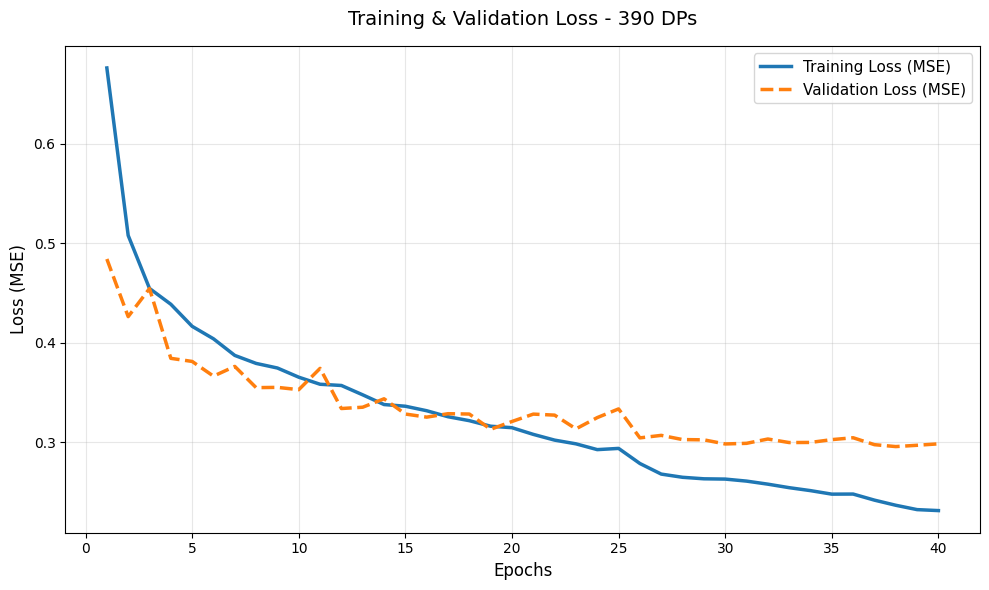

已保存 390 DPs 的损失曲线图: loss_plot_390_DPs.png


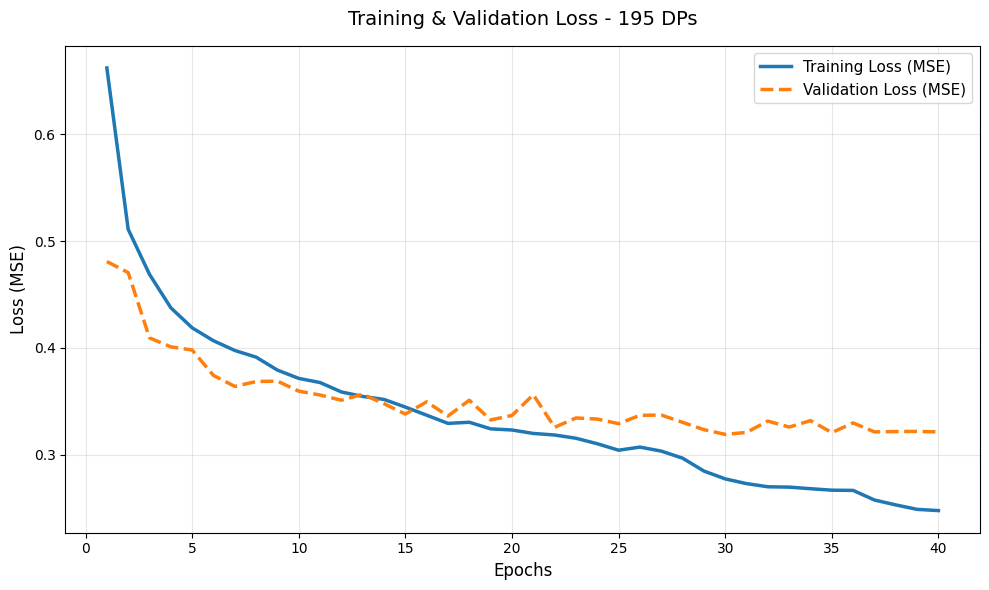

已保存 195 DPs 的损失曲线图: loss_plot_195_DPs.png


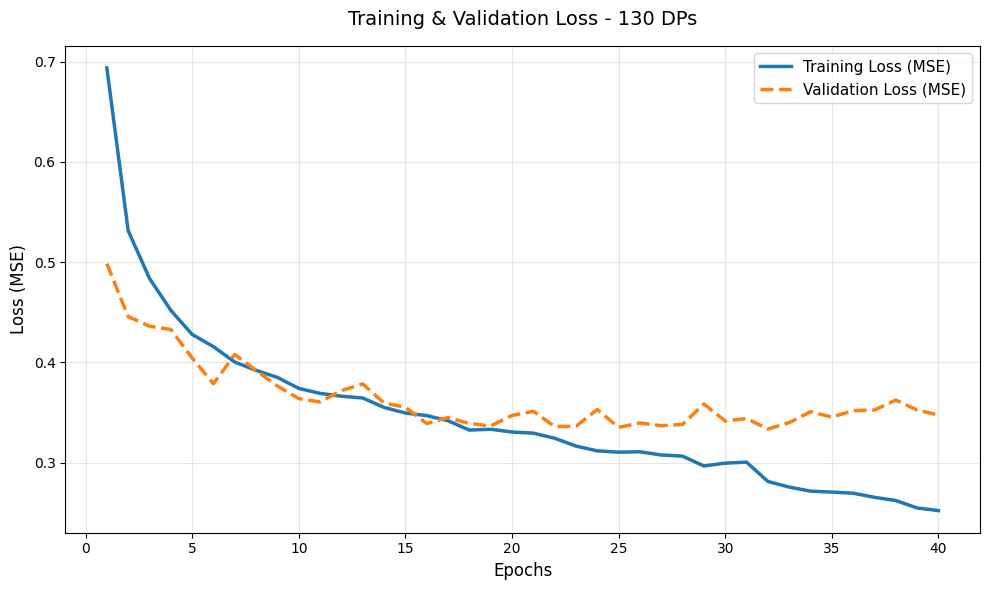

已保存 130 DPs 的损失曲线图: loss_plot_130_DPs.png

结论：最佳的下采样方式为 [1950 DPs]，得到 [1950] 个光谱波段


In [8]:
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
ds_to_plot = ["390 DPs", "195 DPs", "130 DPs"]
colors = ['#1f77b4', '#ff7f0e']  # 训练损失/验证损失
line_styles = ['-', '--']
fig_size = (10, 6)
for idx, config_name in enumerate(ds_to_plot):
    history = downsampled_results[config_name]["history"]
    epochs = range(1, len(history['train_loss']) + 1)
    train_loss = history['train_loss']
    val_loss = history['val_loss']
    plt.figure(figsize=fig_size)
    plt.plot(epochs, train_loss,
             color=colors[0], linestyle=line_styles[0], linewidth=2.5,
             label=f'Training Loss (MSE)')
    plt.plot(epochs, val_loss,
             color=colors[1], linestyle=line_styles[1], linewidth=2.5,
             label=f'Validation Loss (MSE)')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss (MSE)', fontsize=12)
    plt.title(f'Training & Validation Loss - {config_name}', fontsize=14, pad=15)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, linestyle='-')
    plt.tick_params(axis='both', labelsize=10)
    save_name = f'loss_plot_{config_name.replace(" ", "_")}.png'
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"已保存 {config_name} 的损失曲线图: {save_name}")
avg_r2_by_config = {}
for config_name, result in downsampled_results.items():
    avg_r2_by_config[config_name] = np.mean(result['r2_scores'])
best_config_name = max(avg_r2_by_config, key=avg_r2_by_config.get)
best_avg_r2 = avg_r2_by_config[best_config_name]
best_input_dim = downsampled_results[best_config_name]['input_dim']
print(f"\n结论：最佳的下采样方式为 [{best_config_name}]，得到 [{best_input_dim}] 个光谱波段")

100%|██████████| 30/30 [00:04<00:00,  6.27it/s]


特征名称数量: 1950


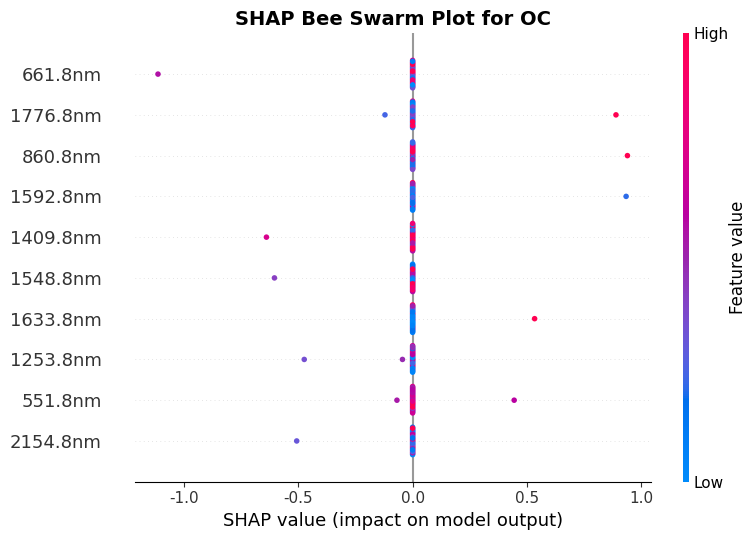

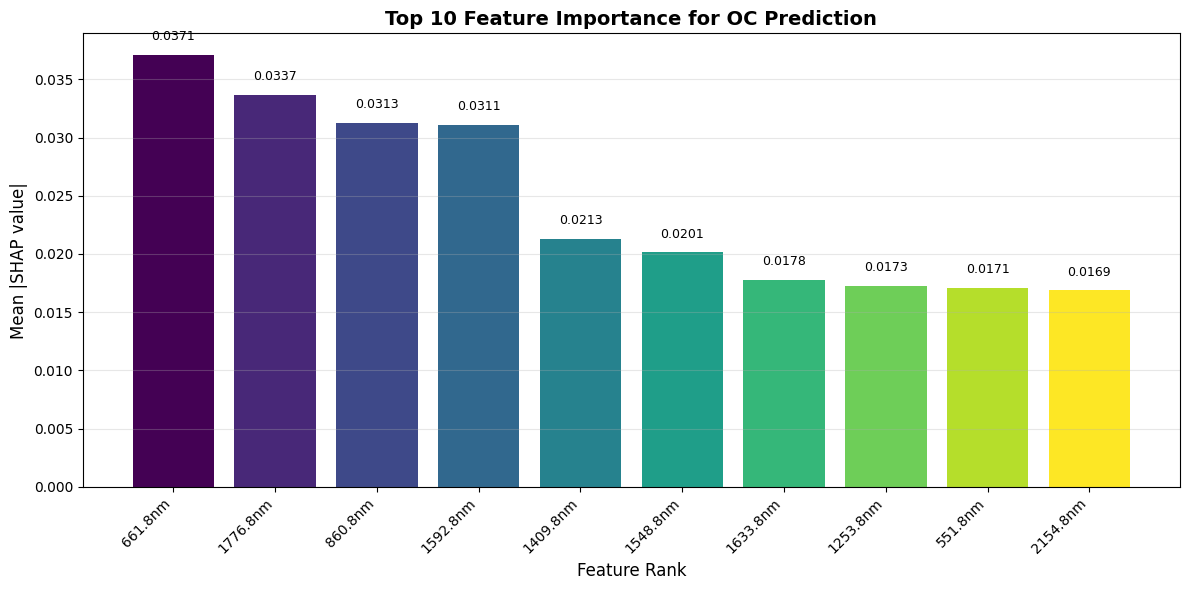


贡献度排名前10的光谱波段:
排名    波长(nm)       重要性            
----------------------------------------
1     661.8        0.037095       
2     1776.8       0.033652       
3     860.8        0.031291       
4     1592.8       0.031100       
5     1409.8       0.021298       
6     1548.8       0.020131       
7     1633.8       0.017769       
8     1253.8       0.017270       
9     551.8        0.017076       
10    2154.8       0.016888       


In [34]:
import shap
best_result = downsampled_results[best_config_name]
model_shap = best_result["model"]
input_dim = best_result["input_dim"]
def model_predict_oc(X):
    model_shap.eval()
    with torch.no_grad():
        if len(X.shape) == 2:
            X_tensor = torch.FloatTensor(X).reshape(-1, 1, 1, X.shape[1]).to(device)
        elif len(X.shape) == 4:
            X_tensor = torch.FloatTensor(X).to(device)
        else:
            raise ValueError(f"Unexpected input shape: {X.shape}")
        predictions = model_shap(X_tensor).cpu().numpy()
    return predictions[:, 0].reshape(-1, 1)
best_merge_nm = best_result["merge_nm"]
X_downsampled, wl_downsampled = downsample_spectra(X_removed, wavelengths_removed, best_merge_nm)
input_dim = X_downsampled.shape[1]
train_indices = X_train.index
test_indices = X_val.index
X_train_ds = X_downsampled[train_indices]
X_test_ds = X_downsampled[test_indices]
spectra_scaler_ds = StandardScaler()
X_train_ds_scaled = spectra_scaler_ds.fit_transform(X_train_ds)
X_test_ds_scaled = spectra_scaler_ds.transform(X_test_ds)
n_background = min(30, len(X_train_ds_scaled))
X_background = shap.sample(X_train_ds_scaled, n_background)
explainer = shap.KernelExplainer(model_predict_oc, X_background)

n_test_shap = min(30, len(X_test_ds_scaled))
X_test_shap_sample = X_test_ds_scaled[:n_test_shap]
shap_values = explainer.shap_values(X_test_shap_sample, nsamples=30)  # 减少nsamples
if len(shap_values.shape) == 3:
    shap_values = shap_values.reshape(shap_values.shape[0], shap_values.shape[1])


# 绘制蜂窝图
plt.figure(figsize=(10, 6))
feature_names = [f"{wl:.1f}nm" for wl in wl_downsampled]
print(f"特征名称数量: {len(feature_names)}")
shap.summary_plot(
    shap_values,
    X_test_shap_sample,
    feature_names=feature_names,
    max_display=10,
    show=False
)
plt.title('SHAP Bee Swarm Plot for OC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bee_swarm_plot_OC.png', dpi=300, bbox_inches='tight')
plt.show()
# 绘制柱状图
plt.figure(figsize=(12, 6))
shap_abs_mean_oc = np.abs(shap_values).mean(axis=0)
top_n = min(10, len(shap_abs_mean_oc))
top_indices_oc = np.argsort(shap_abs_mean_oc)[-top_n:][::-1]
top_importances_oc = shap_abs_mean_oc[top_indices_oc]
if len(wl_downsampled) >= top_n:
    top_wavelengths_oc = wl_downsampled[top_indices_oc]
else:
    top_n = min(top_n, len(wl_downsampled))
    top_indices_oc = top_indices_oc[:top_n]
    top_importances_oc = top_importances_oc[:top_n]
    top_wavelengths_oc = wl_downsampled[top_indices_oc]

bars = plt.bar(range(top_n), top_importances_oc, color=plt.cm.viridis(np.linspace(0, 1, top_n)))
plt.xlabel('Feature Rank', fontsize=12)
plt.ylabel('Mean |SHAP value|', fontsize=12)
plt.title(f'Top {top_n} Feature Importance for OC Prediction', fontsize=14, fontweight='bold')
plt.xticks(range(top_n), [f"{wl:.1f}nm" for wl in top_wavelengths_oc], rotation=45, ha='right')
for i, (bar, imp) in enumerate(zip(bars, top_importances_oc)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{imp:.4f}', ha='center', va='bottom', fontsize=9)

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('shap_bar_plot_OC.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n贡献度排名前{top_n}的光谱波段:")
print(f"{'排名':<5} {'波长(nm)':<12} {'重要性':<15}")
print("-" * 40)
for i, (wl, imp) in enumerate(zip(top_wavelengths_oc, top_importances_oc)):
    print(f"{i+1:<5} {wl:<12.1f} {imp:<15.6f}")

数据形状: (19035, 1950)

开始训练带有1×1卷积核的模型B...

开始训练 ResNet_1x1...
Epoch [001/040]
loss: 0.7203-pH.in.CaCl2_output:0.6233-pH.in.H2O_output:0.6041-OC_output:0.4451-CaCO3_output:0.7869-N_output:0.5323-P_output:0.9944-K_output:0.9625-CEC_output:0.8140-val_loss: 0.5463-val_pH.in.CaCl2_output:0.6233-val_pH.in.H2O_output:0.4302-val_OC_output:0.1683-val_CaCO3_output:0.5438-val_N_output:0.3003-val_P_output:1.3217-val_K_output:0.6587-val_CEC_output:0.5086
Epoch [002/040]
loss: 0.5704-pH.in.CaCl2_output:0.4096-pH.in.H2O_output:0.3961-OC_output:0.3092-CaCO3_output:0.5092-N_output:0.4020-P_output:0.9663-K_output:0.9051-CEC_output:0.6654-val_loss: 0.5659-val_pH.in.CaCl2_output:0.4096-val_pH.in.H2O_output:0.4717-val_OC_output:0.3184-val_CaCO3_output:0.4147-val_N_output:0.3761-val_P_output:1.3152-val_K_output:0.6548-val_CEC_output:0.5034
Epoch [003/040]
loss: 0.5058-pH.in.CaCl2_output:0.3228-pH.in.H2O_output:0.3158-OC_output:0.2606-CaCO3_output:0.3649-N_output:0.3558-P_output:0.9478-K_output:0.8800-CEC_out

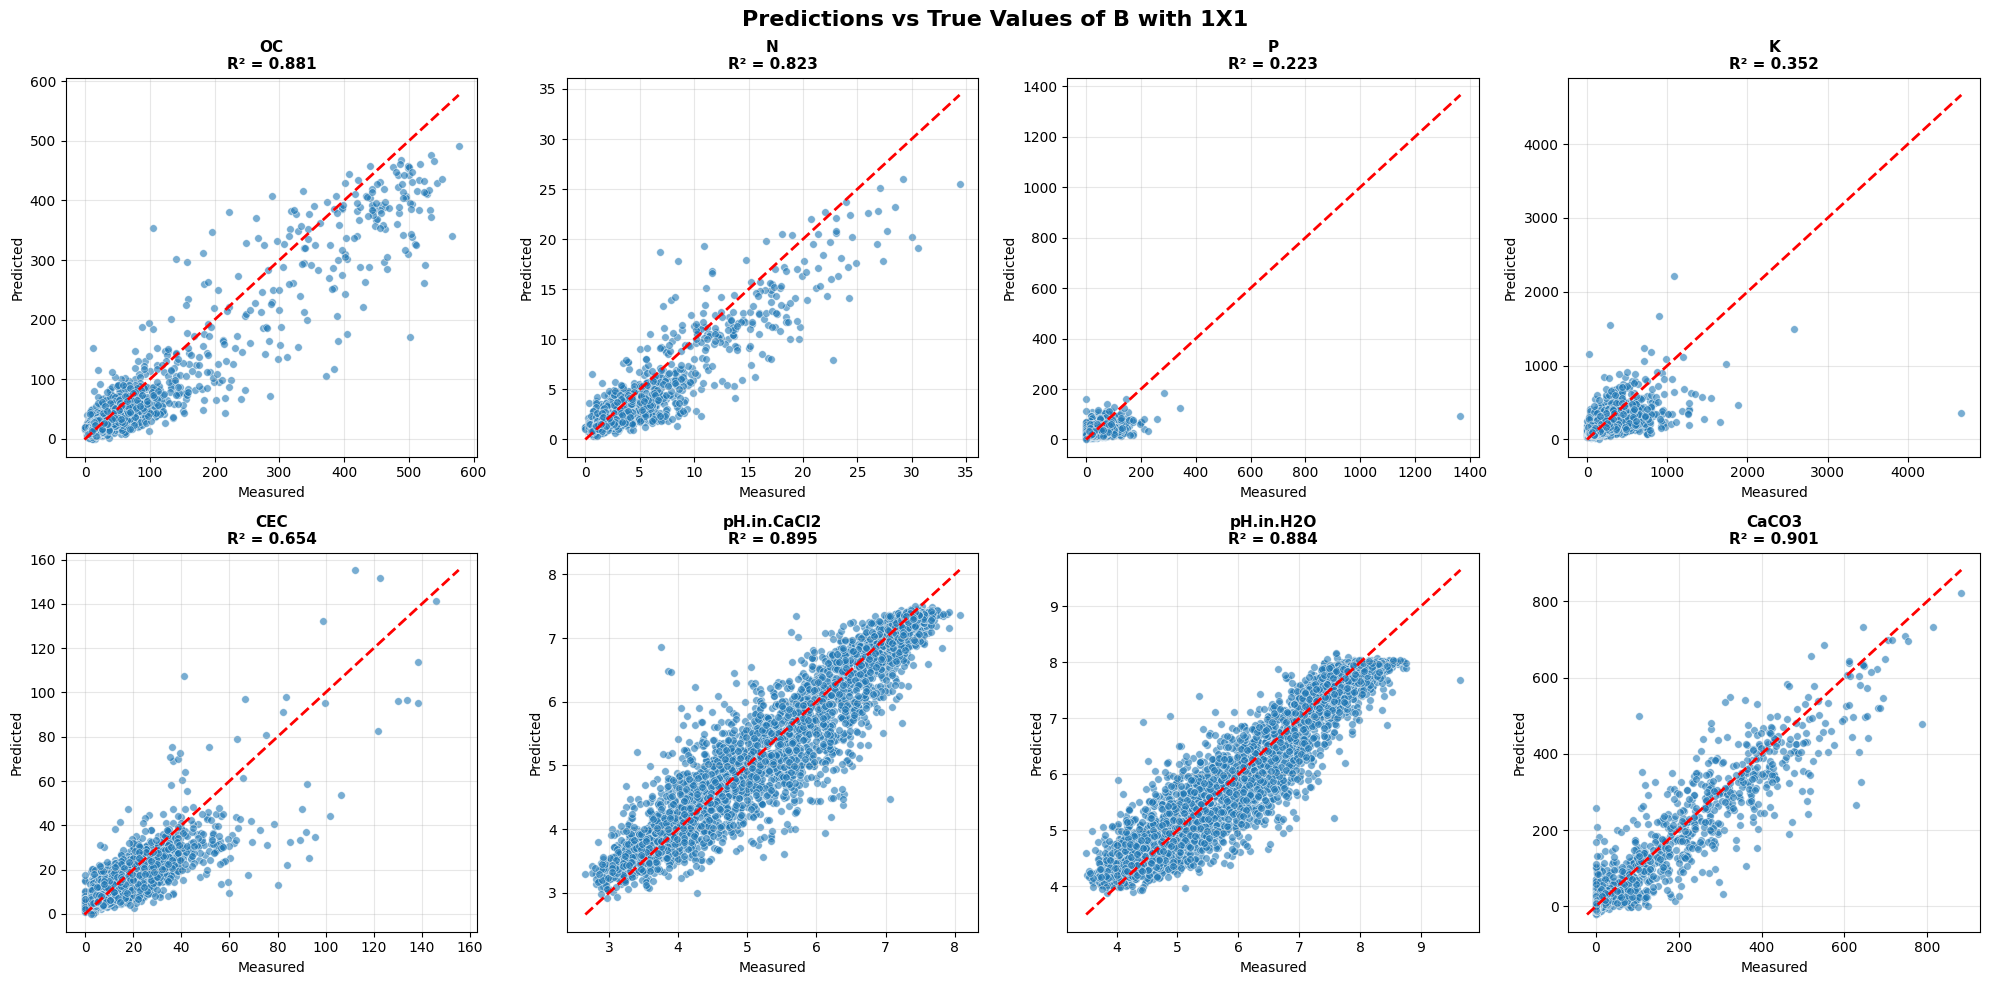

指标              R²         RMSE      
--------------- ---------- ---------- 
OC              0.8814     30.4411   
N               0.8233     1.4916    
P               0.2234     32.5149   
K               0.3524     162.7749  
CEC             0.6539     7.6953    
pH.in.CaCl2     0.8951     0.4622    
pH.in.H2O       0.8841     0.4597    
CaCO3           0.9015     38.3388   
--------------- ---------- ---------- ----------
平均              0.7019     34.2723    18.2813   
在每个残差块(BasicBlock)的第二个3×3卷积层后添加一个1×1卷积层


In [17]:
# ==================== 修改ResNet模型添加1×1卷积核 ====================
class BasicBlock_1x1(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, downsample=None, add_1x1=True):
        super(BasicBlock_1x1, self).__init__()
        self.add_1x1 = add_1x1

        # 第一个卷积层
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 3),
                              stride=stride, padding=(0, 1), bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        # 第二个卷积层
        self.conv2 = nn.Conv2d(out_channels, out_channels * self.expansion,
                              kernel_size=(1, 3), stride=1, padding=(0, 1), bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels * self.expansion)

        # 添加1×1卷积层
        if self.add_1x1:
            self.conv1x1 = nn.Conv2d(out_channels * self.expansion, out_channels * self.expansion,
                                    kernel_size=(1, 1), stride=1, padding=0, bias=False)
            self.bn1x1 = nn.BatchNorm2d(out_channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # 添加1×1卷积
        if self.add_1x1:
            out = self.conv1x1(out)
            out = self.bn1x1(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

class ResNet_1x1(nn.Module):
    def __init__(self, block, layers, num_classes=8, add_1x1=True):
        super(ResNet_1x1, self).__init__()
        self.in_channels = 6
        self.add_1x1 = add_1x1

        # 第一个卷积层
        self.conv1 = nn.Conv2d(1, self.in_channels, kernel_size=(1, 7),
                               stride=2, padding=(0, 3), bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=(1, 3), stride=2, padding=(0, 1))

        # 残差层（添加1×1卷积）
        self.layer1 = self._make_layer(block, 6, layers[0], stride=1, add_1x1=add_1x1)
        self.layer2 = self._make_layer(block, 6, layers[1], stride=2, add_1x1=add_1x1)
        self.layer3 = self._make_layer(block, 12, layers[2], stride=2, add_1x1=add_1x1)
        self.layer4 = self._make_layer(block, 12, layers[3], stride=2, add_1x1=add_1x1)

        # 第二个最大池化层
        self.maxpool2 = nn.MaxPool2d(kernel_size=(1, 3), stride=2, padding=(0, 1))

        # 全局平均池化
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 全连接层
        self.fc1 = nn.Linear(12 * block.expansion, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn_fc2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.bn_fc3 = nn.BatchNorm1d(64)

        # 输出层
        self.fc_out = nn.Linear(64, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1, add_1x1=True):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                         kernel_size=(1, 1), stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample, add_1x1=add_1x1))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels, add_1x1=add_1x1))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.maxpool2(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        # 全连接层
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn_fc2(x)
        x = self.relu(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn_fc3(x)
        x = self.relu(x)

        # 输出层
        x = self.fc_out(x)

        return x

def resnet34_1x1(num_classes=8, add_1x1=True):
    """带有1×1卷积核的ResNet34模型"""
    return ResNet_1x1(BasicBlock_1x1, [3, 4, 6, 3], num_classes=num_classes, add_1x1=add_1x1)
X_processed = sg2_snv
remove_ranges = [(400, 499.5), (2450, 2499.5)]
X_removed, wavelengths_removed = remove_bands(X_processed, wavelengths, remove_ranges)
merge_nm = 1
X_downsampled, wl_downsampled = downsample_spectra(X_removed, wavelengths_removed, merge_nm)
print(f"数据形状: {X_downsampled.shape}")
train_indices = X_train.index
test_indices = X_val.index
X_train_ds = X_downsampled[train_indices]
X_test_ds = X_downsampled[test_indices]
spectra_scaler_ds = StandardScaler()
X_train_ds_scaled = spectra_scaler_ds.fit_transform(X_train_ds)
X_test_ds_scaled = spectra_scaler_ds.transform(X_test_ds)
input_dim = X_train_ds.shape[1]
X_train_tensor_ds = torch.FloatTensor(X_train_ds_scaled).reshape(-1, 1, 1, input_dim)
X_test_tensor_ds = torch.FloatTensor(X_test_ds_scaled).reshape(-1, 1, 1, input_dim)
y_train_tensor_ds = torch.FloatTensor(y_train_scaled)
y_test_tensor_ds = torch.FloatTensor(y_val_scaled)
batch_size = 32
train_dataset_ds = TensorDataset(X_train_tensor_ds, y_train_tensor_ds)
test_dataset_ds = TensorDataset(X_test_tensor_ds, y_test_tensor_ds)
train_loader_ds = DataLoader(train_dataset_ds, batch_size=batch_size, shuffle=True)
test_loader_ds = DataLoader(test_dataset_ds, batch_size=batch_size, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_B_1x1 = resnet34_1x1(num_classes=8, add_1x1=True).to(device)
# 训练参数
num_epochs = 40
learning_rate = 0.001

# 训练模型
print(f"\n开始训练带有1×1卷积核的模型B...")
model_B_trained_1x1, history_1x1 = train_model(
    model_B_1x1, train_loader_ds, test_loader_ds,
    num_epochs=num_epochs, lr=learning_rate, device=device
)

# 评估模型
test_loss_1x1, predictions_1x1, targets_1x1, r2_scores_1x1, mse_scores_1x1, mae_scores_1x1 = evaluate_model(
    model_B_trained_1x1, test_loader_ds, target_scalers, soil_features, device=device
)

# 计算RMSE
rmse_scores_1x1 = [np.sqrt(mse) for mse in mse_scores_1x1]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(soil_features):
    ax = axes[i]

    # 获取真实值和预测值
    y_true = targets_1x1[:, i]
    y_pred = predictions_1x1[:, i]
    r2 = r2_scores_1x1[i]
    # 绘制散点图
    ax.scatter(y_true, y_pred, alpha=0.6, s=30, edgecolors='w', linewidth=0.5)
    # 添加对角线
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

    # 设置标题和标签
    ax.set_title(f'{feature}\nR² = {r2:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Measured', fontsize=10)
    ax.set_ylabel('Predicted', fontsize=10)
    ax.grid(True, alpha=0.3)
plt.suptitle('Predictions vs True Values of B with 1X1', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('带1x1卷积核模型预测散点图.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"{'指标':<15} {'R²':<10} {'RMSE':<10}")
print(f"{'-'*15} {'-'*10} {'-'*10} ")

for i, feature in enumerate(soil_features):
    print(f"{feature:<15} {r2_scores_1x1[i]:<10.4f} {rmse_scores_1x1[i]:<10.4f}")

avg_r2_1x1 = np.mean(r2_scores_1x1)
avg_rmse_1x1 = np.mean(rmse_scores_1x1)
avg_mae_1x1 = np.mean(mae_scores_1x1)
print(f"{'-'*15} {'-'*10} {'-'*10} {'-'*10}")
print(f"{'平均':<15} {avg_r2_1x1:<10.4f} {avg_rmse_1x1:<10.4f} {avg_mae_1x1:<10.4f}")
print("在每个残差块(BasicBlock)的第二个3×3卷积层后添加一个1×1卷积层")
torch.save(model_B_trained_1x1.state_dict(), 'model_B_with_1x1_conv.pth')